In [13]:
import json

with open("C:\\Users\\USER\\BLEY-Dashboard-Dissertation\\dashboard\\data\\london_boroughs.geojson", "r") as f:
    geojson = json.load(f)

print(len(geojson["features"]))

print(geojson["features"][0]["properties"])

32
{'objectid': 1, 'name': 'Kingston upon Thames', 'gss_code': 'E09000021', 'hectares': 3726.117, 'nonld_area': 0, 'ons_inner': 'F', 'sub_2011': 'South', 'st_area(geom)': 37261177.9700004, 'st_perimeter(geom)': 37553.1532044243}


In [14]:
import json
import pandas as pd

# Load data\
df = pd.read_csv("C:\\Users\\USER\\BLEY-Dashboard-Dissertation\\dashboard\\data\\master_dataset.csv")

with open("C:\\Users\\USER\\BLEY-Dashboard-Dissertation\\dashboard\\data\\london_boroughs.geojson") as f:
    geo = json.load(f)

# Borough names from GeoJSON
geo_names = sorted(
    feature["properties"]["name"]
    for feature in geo["features"]
)

# Borough names from CSV
csv_names = sorted(df["borough"].unique())

print("GeoJSON Boroughs:", len(geo_names))
print("CSV Boroughs:", len(csv_names))

# Find mismatches
print("\nMissing in GeoJSON:")
print(set(csv_names) - set(geo_names))

print("\nMissing in CSV:")
print(set(geo_names) - set(csv_names))

GeoJSON Boroughs: 32
CSV Boroughs: 32

Missing in GeoJSON:
set()

Missing in CSV:
set()


In [16]:
import geopandas as gpd

# Read the original GeoJSON
gdf = gpd.read_file("C:\\Users\\USER\\BLEY-Dashboard-Dissertation\\dashboard\\data\\london_boroughs.geojson")

# Check the current coordinate reference system
print(gdf.crs)

# Convert to WGS84
gdf = gdf.to_crs(epsg=4326)

# Save the converted file
gdf.to_file(
    "C:\\Users\\USER\\BLEY-Dashboard-Dissertation\\dashboard\\data\\london_boroughs_wgs84.geojson",
    driver="GeoJSON"
)

print("Done!")

EPSG:4326
Done!


In [17]:
print(gdf.crs)

EPSG:4326


   objectid                  name   gss_code   hectares  nonld_area ons_inner  \
0         1  Kingston upon Thames  E09000021   3726.117       0.000         F   
1         2               Croydon  E09000008   8649.441       0.000         F   
2         3               Bromley  E09000006  15013.487       0.000         F   
3         4              Hounslow  E09000018   5658.541      60.755         F   
4         5                Ealing  E09000009   5554.428       0.000         F   

  sub_2011  st_area(geom)  st_perimeter(geom)  \
0    South   3.726118e+07        37553.153204   
1    South   8.649444e+07        58703.983625   
2    South   1.501349e+08        76164.277784   
3     West   5.658544e+07        57608.364856   
4     West   5.554435e+07        47439.045032   

                                            geometry  
0  POLYGON ((-0.33066 51.32901, -0.3307 51.32893,...  
1  POLYGON ((-0.06399 51.31864, -0.06379 51.31872...  
2  POLYGON ((0.01216 51.2996, 0.01233 51.29918, 0... 

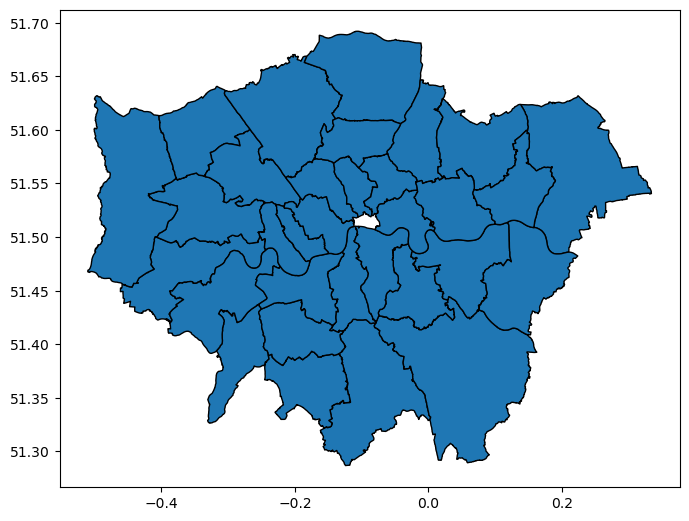

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("C:\\Users\\USER\\BLEY-Dashboard-Dissertation\\dashboard\\data\\london_boroughs_wgs84.geojson")

print(gdf.head())
print(gdf.columns)

fig, ax = plt.subplots(figsize=(8,8))
gdf.plot(ax=ax, edgecolor="black")
plt.show()

In [20]:
print(gdf.columns)

Index(['objectid', 'name', 'gss_code', 'hectares', 'nonld_area', 'ons_inner',
       'sub_2011', 'st_area(geom)', 'st_perimeter(geom)', 'geometry'],
      dtype='object')


In [21]:
print(gdf.total_bounds)

[-0.51035588 51.28675868  0.33404412 51.691877  ]


In [24]:
import plotly.express as px
print(hasattr(px, "choropleth_map"))

True


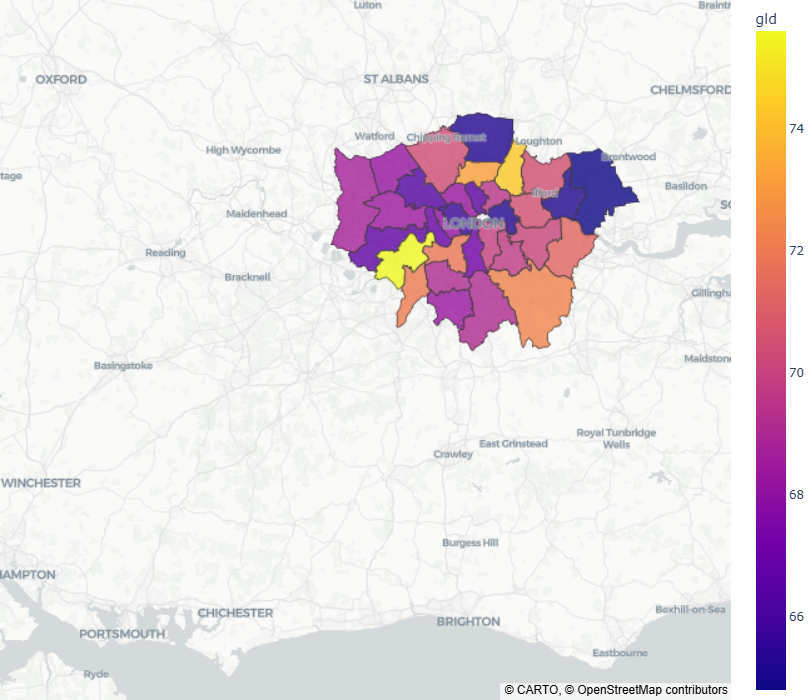

In [27]:
import pandas as pd
import json
import plotly.express as px

# Load your data
df = pd.read_csv("C:\\Users\\USER\\BLEY-Dashboard-Dissertation\\dashboard\\data\\master_dataset.csv")

# Load the GeoJSON
with open("C:\\Users\\USER\\BLEY-Dashboard-Dissertation\\dashboard\\data\\london_boroughs_wgs84.geojson", "r") as f:
    boroughs = json.load(f)

# Create map
fig = px.choropleth_map(
    df,
    geojson=boroughs,
    locations="borough",
    featureidkey="properties.name",
    color="gld",
    hover_name="borough",
    hover_data={
        "gld": True,
        "fsm": True,
        "sen": True,
        "idaci": True,
        "childcare_per_100": True
    },
    center={"lat": 51.5074, "lon": -0.1278},
    zoom=9,
    map_style="carto-positron",
    opacity=0.8,
)

fig.update_layout(
    margin=dict(l=0, r=0, t=0, b=0),
    height=700
)

fig.show()

In [31]:
fig = px.choropleth_map(
    df,
    geojson=boroughs,
    locations="borough",
    featureidkey="properties.name",
    color="gld",
    center={"lat":51.5074,"lon":-0.1278},
    zoom=8.8,
    map_style="carto-positron"
)

print(fig)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [29]:
len(fig.data)


1

In [30]:
len(fig.data)

1

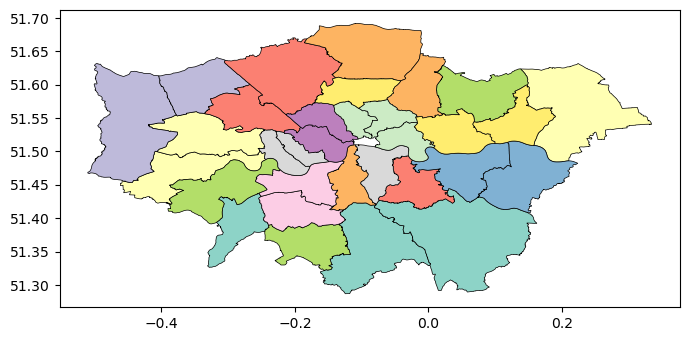

In [32]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("C:\\Users\\USER\\BLEY-Dashboard-Dissertation\\dashboard\\data\\london_boroughs_wgs84.geojson")

fig, ax = plt.subplots(figsize=(8,8))

gdf.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5,
    cmap="Set3"
)

ax.set_aspect("equal")

plt.show()

In [33]:
print(gdf.geometry.is_valid.all())
print(gdf.geometry.is_empty.any())
print(gdf.crs)

True
False
EPSG:4326
